In [34]:
from RRAM import Plot_PostProcess as pplt
from RRAM import Constants as cte
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pickle
import os

num_simulation = 2

In [35]:
carpeta_results = 'Results'

ruta_raiz = 'C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/'

simulation_path = os.path.join(carpeta_results, f'simulation_{num_simulation + 1}/')
figures_path = os.path.join(carpeta_results, 'Figures')


set_simulation_path = os.path.join(carpeta_results, f'simulation_{num_simulation + 1}/set/')
os.makedirs(set_simulation_path, exist_ok=True)

reset_simulation_path = os.path.join(carpeta_results, f'simulation_{num_simulation + 1}/reset/')
os.makedirs(reset_simulation_path, exist_ok=True)


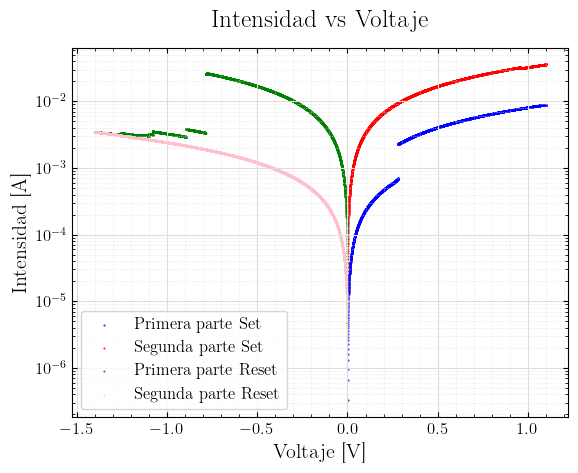

In [36]:
# region Representar datos
data_path_pp_set = set_simulation_path + f'resultados_pp_set_{num_simulation +1}.csv'
data_path_sp_set = set_simulation_path + f'resultados_sp_set_{num_simulation +1}.csv'
data_path_pp_reset = reset_simulation_path + f'resultados_pp_reset_{num_simulation +1}.csv'
data_path_sp_reset = reset_simulation_path + f'resultados_sp_reset_{num_simulation +1}.csv'

df_pset = pd.read_csv(data_path_pp_set, dtype=float)
df_sset = pd.read_csv(data_path_sp_set, dtype=float)
df_preset = pd.read_csv(data_path_pp_reset, dtype=float)
df_sreset = pd.read_csv(data_path_sp_reset, dtype=float)

global_tittle = 'Intensidad vs Voltaje'

save_path = simulation_path + f'Figures/Intensidad_Voltaje_simulation_{num_simulation+1}'

i_ps = np.array(df_pset['Intensidad [A]'])
i_ss = np.array(df_sset['Intensidad [A]'])
i_pr = np.array(df_preset['Intensidad [A]'])
i_sr = np.array(df_sreset['Intensidad [A]'])
v_ps = np.array(df_pset['Voltaje [V]'])
v_ss = np.array(df_sset['Voltaje [V]'])
v_pr = np.array(df_preset['Voltaje [V]'])
v_sr = np.array(df_sreset['Voltaje [V]'])

fig, axes = plt.subplots()

pplt.config_ax(axes)

axes.set_xlabel('Voltaje [V]')
axes.set_ylabel('Intensidad [A]')
axes.set_yscale('log')

axes.set_title(global_tittle, fontsize=18, pad=15)

axes.scatter(v_ps, i_ps, color='blue', s=0.2, label='Primera parte Set')
axes.scatter(v_ss, i_ss, color='red', s=0.2, label='Segunda parte Set')
axes.scatter(v_pr, i_pr, color='green', s=0.2, label='Primera parte Reset')
axes.scatter(v_sr, i_sr, color='pink', s=0.2, label='Segunda parte Reset')

plt.legend()

# Ruta proporcionada
ruta_exp_data = ruta_raiz + 'Datos_Experimentales/Ciclos_Experimentales'
ruta_archivo_set = ruta_exp_data + '/Cycle_p_1000.txt'
ruta_archivo_reset = ruta_exp_data + '/Cycle_n_1000.txt'

# Leer datos del archivo
data_set = np.loadtxt(ruta_archivo_set)
data_reset = np.loadtxt(ruta_archivo_reset)
# Asumimos que los datos están en dos columnas: x e y

x_set = data_set[:, 0]
y_set = data_set[:, 1]

# Data reset
x_reset = data_reset[:, 0]
y_reset = abs(data_reset[:, 1])

In [37]:

# Añado los valores de las variables que estoy cambiando, para eso tengo q ver dentro de la carpeta de init_data el nombre de cada documento, si el nombre conindice con una variable del diccionario, añado el valor que está tomando en la simulación en la representación

# Leer los valores de las variables desde los archivos en Initial_data
init_data_path = 'Initial_data'
variables = {}

for filename in os.listdir(init_data_path):
    if filename.endswith('.pkl'):
        variable_name = filename.split('.')[0]
        with open(os.path.join(init_data_path, filename), 'rb') as f:
            variables[variable_name] = pickle.load(f)

# Crear el subtítulo con los valores de las variables
espacios = ' ' * 3  # Define el número de espacios que deseas añadir

# Construye la lista de subtítulos con espacios y saltos de línea cada tres valores
subtitles = []
for i, (variable_name, value) in enumerate(variables.items()):
    subtitles.append(f'{variable_name} = {value[num_simulation]}')
    if (i + 1) % 3 == 0:
        subtitles.append('\n')
    else:
        subtitles.append(espacios)

In [38]:
# Une los subtítulos en una sola cadena
subtitle = ''.join(subtitles).strip()
fig.suptitle(subtitle, fontsize=11, y=1.05)  # Ajusta el valor de y según sea necesario

# Crear la gráfica scatter
axes.scatter(x_set, y_set, color='black', label='Set experimental')
axes.scatter(x_reset, y_reset, color='black', label='Reset experimental')

plt.show()